# Avaliação qualidade da explicação do XAI

Neste notebook, avaliaremos a qualidade e a confiabilidade das explicações geradas pelos métodos de XAI aplicados ao modelo CNN-LSTM. Enquanto o notebook anterior identificou quais sensores e ciclos temporais são mais relevantes para as previsões de RUL, este estudo verifica se essas explicações realmente representam o comportamento do modelo. Serão realizadas as seguintes avaliações:

1. **Fidelity**: Se remover as variáveis importantes o erro aumenta?
2. **Infidelity**: A explicação realmente representa o modelo?
3. **Stability**: Mudanças pequenas nos dados, explicação muda pouco?
4. **Sparsity**: Quantas variáveis são necessárias para explicar?
5. **Completeness**: A explicação cobre toda a decisão?

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath('../..')) 

from src.xai.xai_baseExplainer import BaseExplainer
from src.xai.xai_shapExplainer import ShapExplainer
from src.xai.xai_limeExplainer import LimeExplainer
from src.xai.xai_igExplainer import IntegratedGradientsExplainer
from src.xai.xai_timeshapExplainer import TimeShapExplainer
from src.xai.xai_windowshapExplainer import WindowShapExplainer
from src.xai.xaI_gradcamExplainer import GradCamExplainer
from src.xai.xai_saliencymapsExplainer import SaliencyMapsExplainer

In [2]:
DATASET_01 = "FD001"
model_path_001 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_01}.keras"
x_path_001 = f"../../data/processed_data/X_test_{DATASET_01}.npz"
y_path_001 = f"../../data/processed_data/y_test_{DATASET_01}.npz"

DATASET_02 = "FD002"
model_path_002 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_02}.keras"
x_path_002 = f"../../data/processed_data/X_test_{DATASET_02}.npz"
y_path_002 = f"../../data/processed_data/y_test_{DATASET_02}.npz"

DATASET_03 = "FD003"
model_path_003 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_03}.keras"
x_path_003 = f"../../data/processed_data/X_test_{DATASET_03}.npz"
y_path_003 = f"../../data/processed_data/y_test_{DATASET_03}.npz"

DATASET_04 = "FD004"
model_path_004 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_04}.keras"
x_path_004 = f"../../data/processed_data/X_test_{DATASET_04}.npz"
y_path_004 = f"../../data/processed_data/y_test_{DATASET_04}.npz"

## 1. Fidelity: a remoção dos sensores mais importantes piora a previsão?

A ideia seria gerar um ranking global de sensores, utilizando 1000 amostras e aplicando o SHAP neles, atribuindo uma pontuação a cada sensor. Após isso, foram feitos 3 testes diferentes para a comparação com o erro que temos no momento, trocando *k* sensores por valores de referência calculados no conjunto de treinamento (mediana) e medimos o impacto no erro. Os testes foram:

 - Substituindo os *k* sensores mais relevantes
 - Substituindo *k* sensores menos relevantes 
 - Substituindo *k* sensores aleatórios

Para uma explicação ser considerada mais fiel, quando removemos os sensores mais importantes, o ideal é o aumento das métricas de erro.

Referências:

https://arxiv.org/abs/1806.07421

https://explainableaiworkbook.com/02-explainable-machine-learning/09-evaluating-explanations/01-fidelity

In [1]:
def obter_atribuicao_2d(explainer, indice):
    """Retorna atribuicoes no formato (tempo, sensores), com os valores das atribuicoes."""
    atribuicao = np.asarray(explainer.explain_instance(indice))
    if atribuicao.ndim == 4: 
        atribuicao = atribuicao[0, :, :, 0]
    elif atribuicao.ndim == 3:
        atribuicao = atribuicao[0]
    return atribuicao

def calcular_metricas(y_real, y_pred):
    """Calcula MAE e RMSE entre y_real e y_pred."""
    erro = y_real.reshape(-1) - y_pred.reshape(-1)
    return np.mean(np.abs(erro)), np.sqrt(np.mean(erro**2))

def ranking_sensores(explainer, num_amostras_explicacao=1000):
    """Calcula um ranking unico pela media de atribuicoes."""
    n = min(num_amostras_explicacao, len(explainer.X_test))
    importancia_global = np.zeros(explainer.X_test.shape[2])
    for indice in range(n):
        atribuicao = obter_atribuicao_2d(explainer, indice)
        importancia_global += np.sum(np.abs(atribuicao), axis=0)
    importancia_global /= n
    return np.argsort(importancia_global)[::-1], importancia_global

def mascarar_sensores(X, sensores, referencia):
    """Mascarar sensores em X com valores de referencia, para avaliacao de fidelity."""
    X_mascarado = X.copy()
    for sensor in sensores:
        X_mascarado[:, :, sensor] = referencia[sensor]
    return X_mascarado

def avaliar_fidelity(explainer, X, y, referencia, k_values=(1, 3, 5), num_amostras_explicacao=1000, seed=42):
    ranking, importancia_global = ranking_sensores(explainer, num_amostras_explicacao)
    mae_original, rmse_original = calcular_metricas(y, explainer.model.predict(X, verbose=0))
    rng, resultados = np.random.default_rng(seed), []
    for k in k_values:
        grupos = {
            "Top-k XAI": ranking[:k],
            "Bottom-k XAI": ranking[-k:],
            "Aleatorio": rng.choice(X.shape[2], size=k, replace=False),
        }
        for estrategia, sensores in grupos.items():
            predicao = explainer.model.predict(mascarar_sensores(X, sensores, referencia), verbose=0)
            mae, rmse = calcular_metricas(y, predicao)
            resultados.append({
                "Estrategia": estrategia, "k sensores removidos": k,
                "Sensores removidos": ", ".join(map(str, explainer.feature_names[sensores])),
                "MAE": mae, "RMSE": rmse,
                "Delta MAE vs. original": mae - mae_original,
                "Delta RMSE vs. original": rmse - rmse_original,
            })
    ranking_df = pd.DataFrame({
        "Sensor": explainer.feature_names[ranking],
        "Importancia media (atribuicao)": importancia_global[ranking],
    })
    return pd.DataFrame(resultados), {"MAE": mae_original, "RMSE": rmse_original}, ranking_df

def plotar_fidelity(resultados, dataset, metodo):
    fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
    for estrategia, grupo in resultados.groupby("Estrategia"):
        eixos[0].plot(grupo["k sensores removidos"], grupo["Delta MAE vs. original"], marker="o", label=estrategia)
        eixos[1].plot(grupo["k sensores removidos"], grupo["Delta RMSE vs. original"], marker="o", label=estrategia)
    for eixo, metrica in zip(eixos, ["MAE", "RMSE"]):
        eixo.axhline(0, color="black", linewidth=0.8)
        eixo.set(xlabel="Numero de sensores removidos (k)", ylabel=f"Delta {metrica} vs. original")
        eixo.grid(alpha=0.3); eixo.legend()
    fig.suptitle(f"Fidelity por remocao - {metodo} - {dataset}")
    plt.tight_layout(); plt.show()


Métricas sem remoção: {'MAE': np.float64(10.09663715143679), 'RMSE': np.float64(14.15571717378156)}


,Sensor,Importancia media (atribuicao)
0,s_11,17.485
1,s_12,14.507
2,s_7,11.687
3,s_15,11.591
4,s_4,10.976
5,s_2,8.450
6,s_20,7.801
7,s_3,6.278
8,s_8,6.134
9,s_21,5.976


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_11,11.119,15.187,1.022,1.031
1,Bottom-k XAI,1,s_5,10.097,14.156,0.000,0.000
2,Aleatorio,1,setting_2,10.003,14.090,-0.094,-0.066
3,Top-k XAI,3,"s_11, s_12, s_7",13.753,19.922,3.656,5.767
4,Bottom-k XAI,3,"s_6, s_16, s_5",10.097,14.157,0.000,0.001
5,Aleatorio,3,"s_14, s_8, s_12",11.397,15.723,1.301,1.567
6,Top-k XAI,5,"s_11, s_12, s_7, s_15, s_4",15.996,24.869,5.899,10.714
7,Bottom-k XAI,5,"s_14, setting_1, s_6, s_16, s_5",10.323,14.327,0.226,0.171
8,Aleatorio,5,"setting_2, s_12, s_20, s_3, s_11",13.779,19.883,3.682,5.727


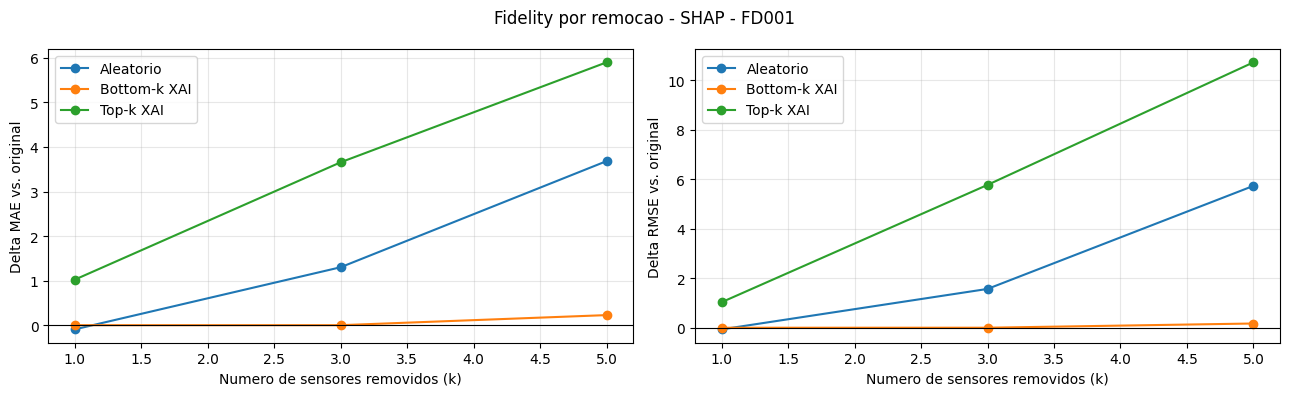

In [4]:
X_train_fd001 = np.load("../../data/processed_data/X_train_FD001.npz")["dados"]
referencia_fd001 = np.median(X_train_fd001, axis=(0, 1))

shap_fd001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)
resultados_fidelity_shap_fd001, metricas_originais_fd001, ranking_shap_fd001 = avaliar_fidelity(
    explainer=shap_fd001, X=shap_fd001.X_test, y=shap_fd001.y_test,
    referencia=referencia_fd001, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd001)
display(ranking_shap_fd001.head(10).round(3))
display(resultados_fidelity_shap_fd001.round(3))
plotar_fidelity(resultados_fidelity_shap_fd001, dataset="FD001", metodo="SHAP")

### FD001

A remocao dos sensores mais importantes aumenta o erro de forma progressiva, com um comportamento semelhante do MAE e RMSE. Os sensores menos importantes praticamente nao alteram o desempenho, reforcando a fidelity do ranking SHAP. O controle aleatorio tambem piora o modelo, principalmente em `k=5` porque incluiu `s_11` e `s_12`(que são sensores considerados importantes). Já retirando os sensores de maior importância gerou os piores resultados, demonstrando a fidelidade.

Métricas sem remoção: {'MAE': np.float64(12.254957572835856), 'RMSE': np.float64(16.319196584738147)}


,Sensor,Importancia media (atribuicao)
0,s_11,22.679
1,s_15,15.560
2,s_4,12.183
3,s_7,8.740
4,s_2,8.475
5,s_17,8.032
6,s_12,7.822
7,s_6,7.184
8,s_21,6.092
9,s_3,5.662


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_11,12.976,16.834,0.721,0.515
1,Bottom-k XAI,1,s_1,12.255,16.319,0.000,0.000
2,Aleatorio,1,setting_3,12.255,16.319,0.000,0.000
3,Top-k XAI,3,"s_11, s_15, s_4",16.073,21.640,3.818,5.321
4,Bottom-k XAI,3,"s_5, setting_3, s_1",12.255,16.319,0.000,0.000
5,Aleatorio,3,"s_15, s_8, s_13",12.937,16.665,0.682,0.346
6,Top-k XAI,5,"s_11, s_15, s_4, s_7, s_2",17.653,24.381,5.398,8.062
7,Bottom-k XAI,5,"s_18, s_19, s_5, setting_3, s_1",12.255,16.319,0.000,0.000
8,Aleatorio,5,"setting_2, s_12, setting_3, s_2, s_10",12.828,16.580,0.573,0.260


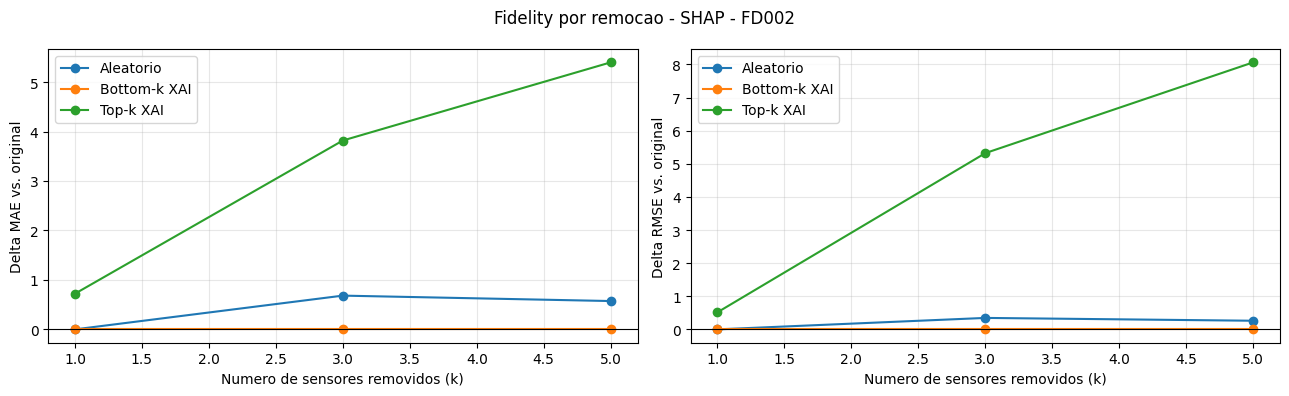

In [5]:
X_train_fd002 = np.load("../../data/processed_data/X_train_FD002.npz")["dados"]
referencia_fd002 = np.median(X_train_fd002, axis=(0, 1))

shap_fd002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)
resultados_fidelity_shap_fd002, metricas_originais_fd002, ranking_shap_fd002 = avaliar_fidelity(
    explainer=shap_fd002, X=shap_fd002.X_test, y=shap_fd002.y_test,
    referencia=referencia_fd002, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd002)
display(ranking_shap_fd002.head(10).round(3))
display(resultados_fidelity_shap_fd002.round(3))
plotar_fidelity(resultados_fidelity_shap_fd002, dataset="FD002", metodo="SHAP")

### FD002

Resultado semelhante ao anterior, com gráficos parecidos. Novamente a fidelidade é comprovada, com a retirada dos sensores mais importantes, as métricas de erro do modelo aumentam bastante, enquanto a retirada dos menos importantes não causa impacto significante no MAE e RMSE.

Métricas sem remoção: {'MAE': np.float64(7.109504470619086), 'RMSE': np.float64(11.139080847668877)}


,Sensor,Importancia media (atribuicao)
0,s_12,37.435
1,s_6,31.857
2,s_7,25.611
3,s_11,17.674
4,s_4,13.163
5,s_13,12.212
6,s_8,10.896
7,s_15,8.549
8,s_21,7.633
9,s_20,6.416


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_12,9.320,15.207,2.211,4.068
1,Bottom-k XAI,1,s_5,7.110,11.139,0.000,0.000
2,Aleatorio,1,setting_2,7.046,11.043,-0.064,-0.096
3,Top-k XAI,3,"s_12, s_6, s_7",9.612,16.411,2.503,5.272
4,Bottom-k XAI,3,"s_10, s_16, s_5",7.105,11.127,-0.005,-0.012
5,Aleatorio,3,"s_13, s_8, s_12",9.974,16.888,2.865,5.748
6,Top-k XAI,5,"s_12, s_6, s_7, s_11, s_4",11.497,19.103,4.387,7.964
7,Bottom-k XAI,5,"s_14, setting_2, s_10, s_16, s_5",7.081,11.065,-0.029,-0.074
8,Aleatorio,5,"setting_2, s_11, s_20, s_3, s_10",8.168,12.930,1.058,1.790


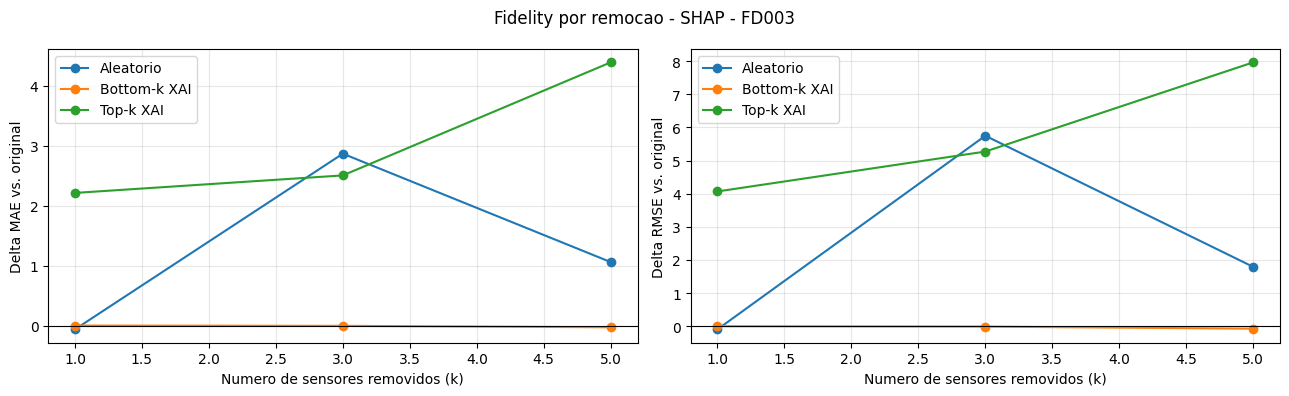

In [6]:
X_train_fd003 = np.load("../../data/processed_data/X_train_FD003.npz")["dados"]
referencia_fd003 = np.median(X_train_fd003, axis=(0, 1))

shap_fd003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)
resultados_fidelity_shap_fd003, metricas_originais_fd003, ranking_shap_fd003 = avaliar_fidelity(
    explainer=shap_fd003, X=shap_fd003.X_test, y=shap_fd003.y_test,
    referencia=referencia_fd003, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd003)
display(ranking_shap_fd003.head(10).round(3))
display(resultados_fidelity_shap_fd003.round(3))
plotar_fidelity(resultados_fidelity_shap_fd003, dataset="FD003", metodo="SHAP")

### FD003

Novamente, a retirada dos sensores mais importantes aumenta consideravelmente as metricas de erro, enquanto a retirada dos menos importantes praticamente nao gera impacto no MAE e RMSE. No teste com `k=3`, a retirada aleatoria ficou levemente pior porque incluiu o `s_12`, que e o sensor mais relevante deste dataset. Mesmo assim, retirando o Top-5 temos o pior resultado geral, demonstrando a fidelity do ranking SHAP.

Métricas sem remoção: {'MAE': np.float64(12.896375828179258), 'RMSE': np.float64(15.928106626038915)}


,Sensor,Importancia media (atribuicao)
0,s_11,23.309
1,s_4,12.121
2,s_9,11.109
3,s_12,7.639
4,s_6,6.470
5,s_7,6.220
6,s_17,5.938
7,s_14,4.725
8,s_3,4.413
9,s_2,3.153


,Estrategia,k sensores removidos,Sensores removidos,MAE,RMSE,Delta MAE vs. original,Delta RMSE vs. original
0,Top-k XAI,1,s_11,14.189,17.613,1.293,1.685
1,Bottom-k XAI,1,s_1,12.896,15.928,0.000,0.000
2,Aleatorio,1,setting_3,12.896,15.928,0.000,0.000
3,Top-k XAI,3,"s_11, s_4, s_9",16.468,21.139,3.572,5.211
4,Bottom-k XAI,3,"s_5, setting_3, s_1",12.896,15.928,0.000,0.000
5,Aleatorio,3,"s_15, s_8, s_13",12.969,15.960,0.072,0.032
6,Top-k XAI,5,"s_11, s_4, s_9, s_12, s_6",16.910,22.647,4.014,6.719
7,Bottom-k XAI,5,"s_18, s_19, s_5, setting_3, s_1",12.896,15.928,0.000,0.000
8,Aleatorio,5,"setting_2, s_12, setting_3, s_2, s_10",13.198,16.074,0.301,0.146


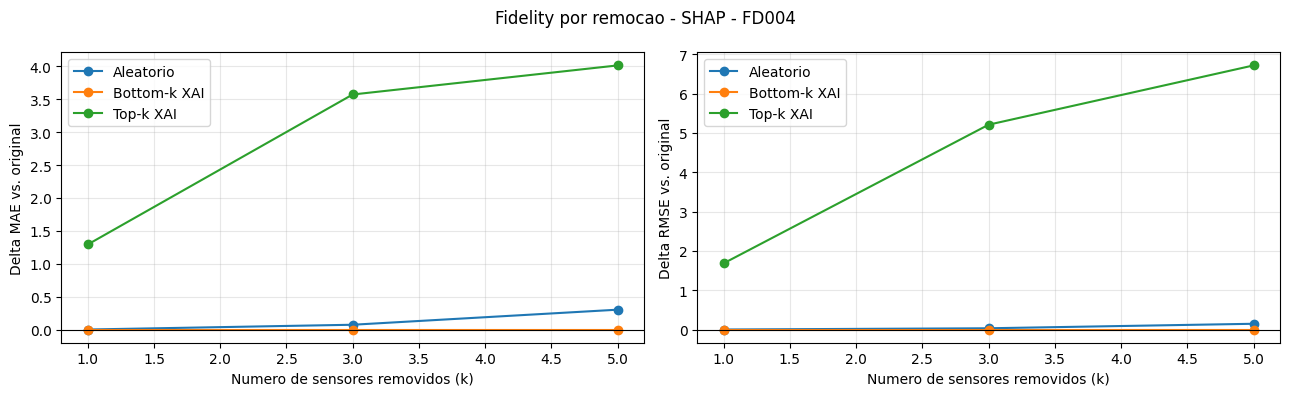

In [7]:
X_train_fd004 = np.load("../../data/processed_data/X_train_FD004.npz")["dados"]
referencia_fd004 = np.median(X_train_fd004, axis=(0, 1))

shap_fd004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)
resultados_fidelity_shap_fd004, metricas_originais_fd004, ranking_shap_fd004 = avaliar_fidelity(
    explainer=shap_fd004, X=shap_fd004.X_test, y=shap_fd004.y_test,
    referencia=referencia_fd004, k_values=(1, 3, 5), num_amostras_explicacao=1000
)

print("Métricas sem remoção:", metricas_originais_fd004)
display(ranking_shap_fd004.head(10).round(3))
display(resultados_fidelity_shap_fd004.round(3))
plotar_fidelity(resultados_fidelity_shap_fd004, dataset="FD004", metodo="SHAP")

### FD004

Mesmo sendo o cenario mais complexo, o resultado segue o padrao dos datasets anteriores: a retirada dos sensores mais importantes aumenta bastante o MAE e o RMSE, principalmente com `k=5`. Ja a retirada dos sensores menos importantes nao causa impacto e a retirada aleatoria gera uma variacao muito menor. Dessa forma, a fidelity tambem e comprovada para o FD004.

### Análise geral - Fidelity

Considerando os quatro datasets, os resultados demonstram que o ranking global gerado pelo SHAP possui fidelity, já que ao neutralizar os sensores mais importantes, o MAE e o RMSE aumentam progressivamente e de forma muito superior a retirada dos sensores menos importantes. Os controles aleatorios tambem apresentam impacto menor na maior parte dos testes, quando eles pioram mais o resultado, como no FD003 com `k=3`, isso ocorre por terem incluido sensores do proprio Top-k (como é aleatório pode acontecer). Portanto, as explicacoes identificam sensores que o modelo realmente utiliza para realizar suas previsoes de RUL.

## 2. **Infidelity**: A explicação realmente representa o modelo?

Referências:

https://captum.ai/api/metrics.html

https://scikit-learn.org/stable/modules/model_evaluation.html#r2-score

O LIME gera uma explicação local para cada janela, atribuindo um peso a cada combinação sensor x ciclo. Em seguida, criamos pequenas perturbações na mesma janela e comparamos duas quantidades: a mudança real do RUL previsto pelo modelo e a mudanca estimada pelos pesos do LIME. A infidelity e o erro quadratico medio entre elas, de forma que quanto menor o valor, melhor a explicação representa o comportamento local do modelo.

In [10]:
def vetor_atribuicoes_lime(explicacao_lime, formato_entrada):
    """Reconstrói os pesos do LIME no mesmo formato sensor x ciclo da entrada."""
    n_tempo, n_sensores = formato_entrada
    pesos = np.zeros(n_tempo * n_sensores)
    rotulo = next(iter(explicacao_lime.local_exp))
    for indice, peso in explicacao_lime.local_exp[rotulo]:
        pesos[int(indice)] = peso
    return pesos

def avaliar_infidelity_lime(explainer, num_instancias=30, num_perturbacoes=30, sigma=0.05, num_amostras_lime=2000, seed=42):
    """
    Mede se a mudança prevista pelos pesos locais do LIME acompanha a mudanca real do modelo sob pequenas perturbações.
    """
    rng = np.random.default_rng(seed)
    n = min(num_instancias, len(explainer.X_test))
    n_tempo, n_sensores = explainer.X_test.shape[1:]
    total_features = n_tempo * n_sensores
    escala = np.asarray(explainer.explainer.scaler.scale_).copy()
    escala[escala == 0] = 1.0
    resultados = []

    for indice in range(n):
        x = explainer.X_test[indice].astype(np.float32)
        explicacao = explainer.explain_instance(
            indice, num_features=total_features, num_samples=num_amostras_lime
        )
        pesos = vetor_atribuicoes_lime(explicacao, (n_tempo, n_sensores))

        perturbacoes = rng.normal(0, sigma, size=(num_perturbacoes, n_tempo, n_sensores))
        x_perturbado = x[None, :, :] - perturbacoes
        mudanca_real = (
            explainer.model.predict(x[None, :, :], verbose=0).reshape(-1)[0]
            - explainer.model.predict(x_perturbado, verbose=0).reshape(-1)
        )

        perturbacoes_lime = perturbacoes.transpose(0, 2, 1).reshape(num_perturbacoes, -1)
        mudanca_estimada = (perturbacoes_lime / escala) @ pesos
        infidelity = np.mean((mudanca_estimada - mudanca_real) ** 2)

        resultados.append({
            "Amostra": indice,
            "RUL previsto": explainer.model.predict(x[None, :, :], verbose=0).reshape(-1)[0],
            "Infidelity": infidelity,
            "Fidelidade local do LIME (R2)": explicacao.score,
        })

    resultados = pd.DataFrame(resultados)
    resumo = resultados[["Infidelity", "Fidelidade local do LIME (R2)"]].agg(["mean", "std", "median"])
    return resultados, resumo


In [11]:
lime_fd001 = LimeExplainer(
    model_path_001, x_path_001, y_path_001,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd001, resumo_infidelity_fd001 = avaliar_infidelity_lime(
    lime_fd001, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)

display(resumo_infidelity_fd001.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,109.4719,0.8816
std,54.2146,0.0054
median,86.7587,0.8813


### Analise - FD001

O LIME obteve R2 local uma média de 0.882, indicando que sua aproximação linear representa bem as previsões do modelo na vizinhança das janelas analisadas. A infidelity teve média de 109.47, com mediana de 86.76, resultado que vamos comparar com os próximos datasets.

In [12]:
lime_fd002 = LimeExplainer(
    model_path_002, x_path_002, y_path_002,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd002, resumo_infidelity_fd002 = avaliar_infidelity_lime(
    lime_fd002, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)
display(resumo_infidelity_fd002.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,85.4833,0.8503
std,50.6258,0.0065
median,77.8860,0.8493


### Analise - FD002

O FD002 apresentou média de infidelity de 85.48, menor que a observada no FD001. O R2 local obteve média de 0.85, que mostra que o LIME continua aproximando bem o comportamento do modelo nas janelas analisadas. Portanto, para este dataset, os pesos do LIME acompanham de forma consistente as pequenas variações na previsao do RUL.

In [13]:
lime_fd003 = LimeExplainer(
    model_path_003, x_path_003, y_path_003,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd003, resumo_infidelity_fd003 = avaliar_infidelity_lime(
    lime_fd003, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)
display(resumo_infidelity_fd003.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,237.0377,0.8747
std,128.5568,0.0055
median,191.1138,0.8749


### Analise - FD003

O FD003 apresentou a maior média infidelity, com 237.04, indicando maior diferença entre a mudança estimada pelo LIME e a mudança real do modelo, com as pertubações. Mesmo assim, o R2 local de 0.875 permanece alto, mostrando que o modelo linear local se ajusta bem as janelas. A maior complexidade associada aos dois modos de falha pode tornar as respostas do modelo mais difíceis de representar, logo com pequenas mudanças o modelo pode acabar tendo um infidelity maior.

In [14]:
lime_fd004 = LimeExplainer(
    model_path_004, x_path_004, y_path_004,
    background_size=500, discretize_continuous=False, random_state=42
)
resultados_infidelity_fd004, resumo_infidelity_fd004 = avaliar_infidelity_lime(
    lime_fd004, num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42
)
display(resumo_infidelity_fd004.round(4))

,Infidelity,Fidelidade local do LIME (R2)
mean,17.2002,0.6903
std,3.3590,0.0105
median,16.7000,0.6905


### Análise - FD004

O FD004 apresentou a menor infidelity média, 17.20. Isso é numericamente coerente, mas não permite concluir sozinho que o LIME é melhor neste dataset: como a infidelity é um erro absoluto, ela também fica baixa se o modelo variar pouco diante das perturbações pequenas usadas no teste. O R² local médio de 0.69, inferior aos outros datasets, mostra que a aproximação linear do LIME foi menos precisa, então as duas métricas devem ser interpretadas em conjunto.

### Análise geral - Infidelity

No geral, o LIME apresentou R2 local alto em FD001, FD002 e FD003, indicando que suas explicações lineares locais representam bem o comportamento da rede nas janelas analisadas. A infidelity variou entre os datasets, sendo maior no FD003 e menor no FD004. Essas métricas devem ser avaliadas juntas: a infidelity mede o erro ao prever pequenas mudanças na saída, enquanto o R2 mede a qualidade do ajuste linear local. Assim, os resultados mostram que a qualidade da explicação depende do dataset e da perturbação, sem permitir concluir apenas pela infidelity que um modelo é mais explicável que outro.

## 3. **Stability**: Mudanças pequenas nos dados, explicação muda pouco?

## 4. **Sparsity**: Quantas variáveis são necessárias para explicar?

## 5. **Completeness**: A explicação cobre toda a decisão?

Estudar:

https://aix360.factsheets.vpc.res.ibm.com/

https://pair-code.github.io/what-if-tool/learn/